In [40]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [41]:
# Chargement des fichiers 

file_path = r"C:\Users\MX6740\OneDrive - ENGIE\Documents\Data DA ID\data_acp_method.xlsx"

df = pd.read_excel(file_path)

# suppression des colonnes inutiles
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

print(df.shape)

df.head()

(1048575, 30)


,application_date,id_vwap_fr,da_storm_fr,spread id-da_fr,da_storm_de,spread id-da_de,da_storm_be,spread id-da_be,da_storm_ch,spread id-da_ch,...,pv_fr_storm,wind_fr_storm,biomass_fr_storm,blast_gas_fr_storm,coal_fr_storm,free_fuel_fr_storm,hydro_fr_storm,nat_gas_fr_storm,nuclear_fr_storm,pump_fr_storm
0,2025-10-01 00:00:00+00:00,43.626318,62.781038,-19.154720,92.823599,-49.197281,85.028114,-41.401796,95.667173,-52.040855,...,0.0,2679.0,170.0,0.0,0.0,1300.0,4620.402611,244.965335,44796.90071,518.433885
1,2025-10-01 01:00:00+00:00,37.378636,62.493387,-25.114751,93.399464,-56.020828,85.403241,-48.024605,96.316262,-58.937627,...,0.0,2442.0,170.0,0.0,0.0,1300.0,4620.402611,244.965335,44786.01860,-680.510551
2,2025-10-01 02:00:00+00:00,43.223529,55.194615,-11.971085,96.983280,-53.759751,82.235118,-39.011589,97.240042,-54.016513,...,0.0,2253.0,170.0,0.0,0.0,1300.0,4620.402611,244.965335,44786.01860,-1469.744516
3,2025-10-01 03:00:00+00:00,22.386379,62.781038,-40.394659,105.824834,-83.438455,79.786115,-57.399735,105.824834,-83.438455,...,0.0,2135.0,170.0,0.0,0.0,1300.0,4620.402611,244.965335,44786.01860,-828.138799
4,2025-10-01 04:00:00+00:00,57.228210,62.781038,-5.552828,134.953865,-77.725654,94.882998,-37.654788,134.953865,-77.725654,...,0.0,2066.0,170.0,0.0,0.0,1300.0,4620.402611,263.511636,44786.01860,229.762638


Création des variables

In [42]:
# Variables météo renouvelables STORM

df["res_total_storm"] = (
    df["pv_fr_storm"]
    + df["wind_fr_storm"]
)

In [43]:
# Varaibles météo renouvelables ARPEGE

df["res_total_arpege"] = (
    df["pv_fr_arpege"]
    + df["wind_fr_arpege"]
)

In [44]:
# Incertitude forecast solaire

df["pv_diff"] = (
    df["pv_fr_storm"]
    - df["pv_fr_arpege"]
)

In [45]:
# Incertitude forecast éolien

df["wind_diff"] = (
    df["wind_fr_storm"]
    - df["wind_fr_arpege"]
)

In [46]:
# Incertitude forecast renouvelable total

df["res_diff"] = (
    df["res_total_storm"]
    - df["res_total_arpege"]
)

In [47]:
# Net load (charge résiduel)

df["net_load"] = (
    df["load_fct_fr"]
    - df["pv_fr_storm"]
    - df["wind_fr_storm"]
)

In [48]:
# Part de renouvelable

df["res_share"] = (
    df["pv_fr_storm"]
    + df["wind_fr_storm"]
) / df["load_fct_fr"]

In [49]:
# Production pilotable

df["dispatchable"] = (
    df["nat_gas_fr_storm"]
    + df["nuclear_fr_storm"]
    + df["hydro_fr_storm"]
    + df["coal_fr_storm"]
)

In [50]:
# Hydro flex

df["hydro_flex"] = (
    df["hydro_fr_storm"]
    + df["pump_fr_storm"]
)

In [51]:
# =====================================
# WIND RAMP SPEEDS - STORM
# =====================================

for h in range(3, 13):

    df[f"wind_ramp_{h}h_storm"] = (
        df["wind_fr_storm"]
        - df["wind_fr_storm"].shift(h)
    )

    df[f"wind_ramp_speed_{h}h_storm"] = (
        df[f"wind_ramp_{h}h_storm"]
        .abs()
    )


# =====================================
# WIND RAMP SPEEDS - ARPEGE
# =====================================

for h in range(3, 13):

    df[f"wind_ramp_{h}h_arpege"] = (
        df["wind_fr_arpege"]
        - df["wind_fr_arpege"].shift(h)
    )

    df[f"wind_ramp_speed_{h}h_arpege"] = (
        df[f"wind_ramp_{h}h_arpege"]
        .abs()
    )


# =====================================
# SOLAR RAMP SPEEDS - STORM
# =====================================

for h in range(3, 13):

    df[f"solar_ramp_{h}h_storm"] = (
        df["pv_fr_storm"]
        - df["pv_fr_storm"].shift(h)
    )

    df[f"solar_ramp_speed_{h}h_storm"] = (
        df[f"solar_ramp_{h}h_storm"]
        .abs()
    )


# =====================================
# SOLAR RAMP SPEEDS - ARPEGE
# =====================================

for h in range(3, 13):

    df[f"solar_ramp_{h}h_arpege"] = (
        df["pv_fr_arpege"]
        - df["pv_fr_arpege"].shift(h)
    )

    df[f"solar_ramp_speed_{h}h_arpege"] = (
        df[f"solar_ramp_{h}h_arpege"]
        .abs()
    )

C:\Users\MX6740\AppData\Local\Temp\ipykernel_13252\830576138.py:58: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"solar_ramp_{h}h_arpege"] = (
C:\Users\MX6740\AppData\Local\Temp\ipykernel_13252\830576138.py:63: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"solar_ramp_speed_{h}h_arpege"] = (


In [52]:
# ==========================================
# INDICATEURS DE RAMPES - VENT
# ==========================================

wind_storm_cols = [
    f"wind_ramp_speed_{h}h_storm"
    for h in range(3, 13)
]

wind_arpege_cols = [
    f"wind_ramp_speed_{h}h_arpege"
    for h in range(3, 13)
]

df["wind_max_ramp_storm"] = df[wind_storm_cols].max(axis=1)
df["wind_mean_ramp_storm"] = df[wind_storm_cols].mean(axis=1)

df["wind_max_ramp_arpege"] = df[wind_arpege_cols].max(axis=1)
df["wind_mean_ramp_arpege"] = df[wind_arpege_cols].mean(axis=1)

# Désaccord entre modèles

df["wind_model_disagreement"] = (
    df["wind_mean_ramp_storm"]
    - df["wind_mean_ramp_arpege"]
).abs()


# ==========================================
# INDICATEURS DE RAMPES - SOLAIRE
# ==========================================

solar_storm_cols = [
    f"solar_ramp_speed_{h}h_storm"
    for h in range(3, 13)
]

solar_arpege_cols = [
    f"solar_ramp_speed_{h}h_arpege"
    for h in range(3, 13)
]

df["solar_max_ramp_storm"] = df[solar_storm_cols].max(axis=1)
df["solar_mean_ramp_storm"] = df[solar_storm_cols].mean(axis=1)

df["solar_max_ramp_arpege"] = df[solar_arpege_cols].max(axis=1)
df["solar_mean_ramp_arpege"] = df[solar_arpege_cols].mean(axis=1)

# Désaccord entre modèles

df["solar_model_disagreement"] = (
    df["solar_mean_ramp_storm"]
    - df["solar_mean_ramp_arpege"]
).abs()


# ==========================================
# INDICE GLOBAL DE VOLATILITE RES
# ==========================================

df["renewable_ramp_stress"] = (
    df["wind_mean_ramp_storm"]
    + df["solar_mean_ramp_storm"]
)

C:\Users\MX6740\AppData\Local\Temp\ipykernel_13252\4018177007.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["wind_max_ramp_storm"] = df[wind_storm_cols].max(axis=1)
C:\Users\MX6740\AppData\Local\Temp\ipykernel_13252\4018177007.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["wind_mean_ramp_storm"] = df[wind_storm_cols].mean(axis=1)
C:\Users\MX6740\AppData\Local\Temp\ipykernel_13252\4018177007.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many ti

In [62]:
# Variable ACP

acp_features = [

    "load_fct_fr",
    "water quantity",

    "net_load",
    "res_share",

    "pv_diff",
    "wind_diff",
    "res_diff",

    "dispatchable",
    "hydro_flex",

    "wind_max_ramp_storm",
    "wind_mean_ramp_storm",

    "wind_max_ramp_arpege",
    "wind_mean_ramp_arpege",

    "solar_max_ramp_storm",
    "solar_mean_ramp_storm",

    "solar_max_ramp_arpege",
    "solar_mean_ramp_arpege",

    "wind_model_disagreement",
    "solar_model_disagreement",

    "renewable_ramp_stress",
 
    "spread id-da_de",
    "spread id-da_be",
    "spread id-da_ch",
    "spread id-da_uk",
    "spread id-da_es",
    "spread id-da_it"

]

In [63]:
# Nettoyage ACP

df_acp = df[
    acp_features + ["spread id-da_fr"]
].dropna()

print(df_acp.shape)

(4985, 27)


In [64]:
# Corrélations simples

corr = (
    df_acp
    .corr(numeric_only=True)["spread id-da_fr"]
)

corr = corr.reindex(
    corr.abs().sort_values(ascending=False).index
)

print(corr)

spread id-da_fr             1.000000
spread id-da_be             0.706251
spread id-da_uk             0.647212
spread id-da_ch             0.609527
spread id-da_it             0.579818
spread id-da_es             0.579426
spread id-da_de             0.507409
pv_diff                     0.206628
solar_model_disagreement   -0.179575
net_load                    0.126357
hydro_flex                  0.126011
dispatchable                0.120970
res_diff                    0.108560
res_share                  -0.106600
load_fct_fr                 0.089173
solar_mean_ramp_arpege     -0.087436
renewable_ramp_stress      -0.079307
solar_mean_ramp_storm      -0.070329
solar_max_ramp_arpege      -0.063486
solar_max_ramp_storm       -0.052370
water quantity             -0.041905
wind_max_ramp_storm        -0.041644
wind_max_ramp_arpege       -0.041461
wind_mean_ramp_storm       -0.036459
wind_mean_ramp_arpege      -0.033796
wind_diff                   0.011742
wind_model_disagreement    -0.009849
N

In [65]:
# Standardisation

X = df_acp[acp_features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [66]:
# ACP

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

In [67]:
# Variance expliquée

explained = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(acp_features))],
    "Variance": pca.explained_variance_ratio_
})

print(explained.head(15))

      PC  Variance
0    PC1  0.263692
1    PC2  0.156677
2    PC3  0.148392
3    PC4  0.098800
4    PC5  0.083224
5    PC6  0.043757
6    PC7  0.040431
7    PC8  0.035898
8    PC9  0.030561
9   PC10  0.020909
10  PC11  0.018029
11  PC12  0.015464
12  PC13  0.011034
13  PC14  0.007676
14  PC15  0.006961


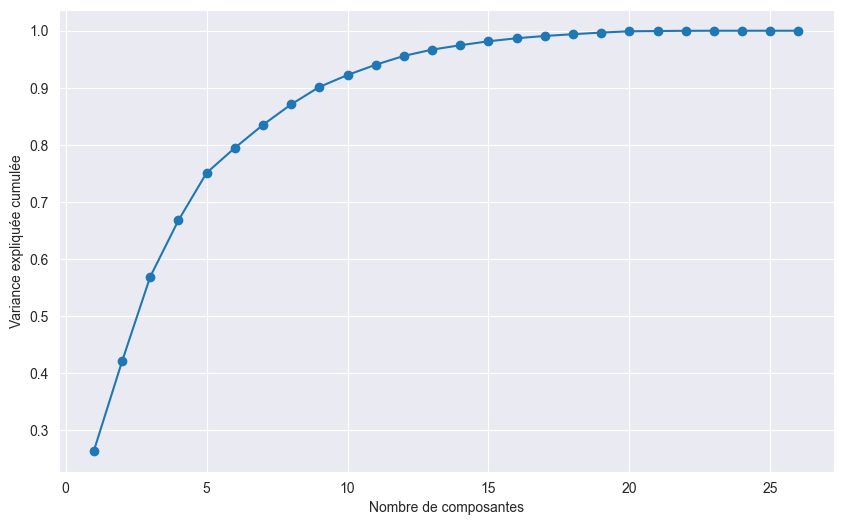

In [68]:
# Variance cumulée

cum_var = np.cumsum(
    pca.explained_variance_ratio_
)

plt.figure(figsize=(10,6))

plt.plot(
    range(1,len(cum_var)+1),
    cum_var,
    marker="o"
)

plt.xlabel("Nombre de composantes")
plt.ylabel("Variance expliquée cumulée")

plt.grid(True)

plt.show()

In [69]:
# Loading ACP

loadings = pd.DataFrame(
    pca.components_.T,
    index=acp_features,
    columns=[
        f"PC{i+1}"
        for i in range(len(acp_features))
    ]
)

loadings[["PC1","PC2","PC3","PC4","PC5"]].round(3)

,PC1,PC2,PC3,PC4,PC5
load_fct_fr,0.208,0.040,0.172,-0.266,-0.131
water quantity,0.071,-0.075,-0.121,0.197,0.157
net_load,0.282,0.053,0.146,-0.269,-0.209
res_share,-0.237,-0.045,-0.017,0.142,0.216
pv_diff,0.105,-0.005,-0.024,-0.197,0.391
wind_diff,0.087,-0.055,-0.007,-0.244,0.416
res_diff,0.121,-0.047,-0.017,-0.291,0.522
dispatchable,0.277,0.020,0.117,-0.319,-0.168
hydro_flex,0.178,0.067,0.111,-0.327,-0.207
wind_max_ramp_storm,-0.104,-0.271,0.377,0.016,0.032


In [70]:
# Scores ACP

pca_scores = pd.DataFrame(
    X_pca[:, :5],
    columns=[
        "PC1",
        "PC2",
        "PC3",
        "PC4",
        "PC5"
    ]
)

pca_scores["spread"] = (
    df_acp["spread id-da_fr"]
    .values
)

In [71]:
# Corrélation PC vs Spread

corr_pc = (
    pca_scores
    .corr()
    ["spread"]
    .sort_values(key=abs, ascending=False)
)

print(corr_pc)

spread    1.000000
PC1       0.430353
PC4       0.316883
PC3       0.277876
PC2       0.277631
PC5       0.232428
Name: spread, dtype: float64


In [73]:
for pc in ["PC1", "PC2", "PC3", "PC4", "PC5"]:

    print("\n")
    print("=" * 60)
    print(pc)
    print("=" * 60)

    s = loadings[pc].abs().sort_values(ascending=False)

    print(s.head(10))



PC1
net_load                  0.282366
spread id-da_it           0.280215
spread id-da_uk           0.276787
dispatchable              0.276689
renewable_ramp_stress     0.257323
solar_mean_ramp_arpege    0.242769
res_share                 0.236719
solar_max_ramp_arpege     0.233471
solar_mean_ramp_storm     0.231919
spread id-da_ch           0.227266
Name: PC1, dtype: float64


PC2
solar_mean_ramp_storm     0.342870
solar_mean_ramp_arpege    0.339530
solar_max_ramp_storm      0.322619
solar_max_ramp_arpege     0.320721
wind_max_ramp_arpege      0.282642
wind_max_ramp_storm       0.271309
wind_mean_ramp_arpege     0.256493
spread id-da_ch           0.254934
wind_mean_ramp_storm      0.242370
renewable_ramp_stress     0.206765
Name: PC2, dtype: float64


PC3
wind_mean_ramp_storm       0.395071
wind_mean_ramp_arpege      0.383427
wind_max_ramp_storm        0.377475
wind_max_ramp_arpege       0.370663
renewable_ramp_stress      0.266529
spread id-da_be            0.196522
spread id-da_d

Par plages horaires

In [74]:
# Conversion date

# Conversion datetime

df["application_date"] = pd.to_datetime(
    df["application_date"]
)

# Période d'étude

start_date = pd.Timestamp(
    "2025-11-01 00:00:00",
    tz="UTC"
)

end_date = pd.Timestamp(
    "2026-04-27 00:00:00",
    tz="UTC"
)

df = df[
    (df["application_date"] >= start_date)
    &
    (df["application_date"] <= end_date)
].copy()

print(df.shape)

# Heure

df["hour"] = df["application_date"].dt.hour

# Découpage horaire marché power

df["time_block"] = np.select(

    [
        df["hour"].between(0, 5),
        df["hour"].between(6, 9),
        df["hour"].between(10, 16),
        df["hour"].between(17, 21),
        df["hour"].between(22, 23)
    ],

    [
        "Night",
        "Morning Peak",
        "Solar Hours",
        "Evening Peak",
        "Late Evening"
    ],

    default="Unknown"

)

# Vérification

print(df.groupby("time_block").size())

(4249, 130)
time_block
Evening Peak     885
Late Evening     354
Morning Peak     708
Night           1063
Solar Hours     1239
dtype: int64


In [75]:
# Heure

df["hour"] = df["application_date"].dt.hour

# Blocs horaires

df["time_block"] = np.select(

    [
        df["hour"].between(0, 5),
        df["hour"].between(6, 9),
        df["hour"].between(10, 16),
        df["hour"].between(17, 21),
        df["hour"].between(22, 23)
    ],

    [
        "Night",
        "Morning Peak",
        "Solar Hours",
        "Evening Peak",
        "Late Evening"
    ],

    default="Unknown"

)

In [76]:
df["month"] = df["application_date"].dt.month

def get_season(month):

    if month in [10, 11]:
        return "Autumn"

    elif month in [12, 1, 2]:
        return "Winter"

    elif month in [3, 4]:
        return "Spring"

    else:
        return np.nan

df["season"] = df["month"].apply(get_season)

In [77]:
df["month"] = df["application_date"].dt.month

def get_season(month):

    if month in [10, 11]:
        return "Autumn"

    elif month in [12, 1, 2]:
        return "Winter"

    elif month in [3, 4]:
        return "Spring"

    else:
        return np.nan

df["season"] = df["month"].apply(get_season)

In [79]:
holidays = pd.to_datetime([

    "2025-11-01",
    "2025-11-11",
    "2025-12-25",
    "2026-01-01",
    "2026-04-06"

]).date

df["weekday"] = df["application_date"].dt.dayofweek

df["date_only"] = df["application_date"].dt.date

df["day_type"] = np.where(

    (
        (df["weekday"] >= 5)
        |
        (df["date_only"].isin(holidays))
    ),

    "Weekend_Holiday",

    "Weekday"

)

In [ ]:
# Vérification

print(df["season"].value_counts())

print(df["day_type"].value_counts())

print(df["time_block"].value_counts())

In [82]:
def run_pca_segment(df_segment):

    df_segment = (
        df_segment[
            acp_features + ["spread id-da_fr"]
        ]
        .dropna()
    )

    if len(df_segment) < 50:
        return None

    X = df_segment[acp_features]

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(X)

    pca = PCA()

    X_pca = pca.fit_transform(X_scaled)

    pca_scores = pd.DataFrame(
        X_pca[:, :5],
        columns=[
            "PC1",
            "PC2",
            "PC3",
            "PC4",
            "PC5"
        ]
    )

    pca_scores["spread"] = (
        df_segment["spread id-da_fr"]
        .values
    )

    corr_pc = (
        pca_scores
        .corr()
        ["spread"]
        .drop("spread")
    )

    best_pc = corr_pc.abs().idxmax()

    return {
    
        "n_obs": len(df_segment),
    
        "best_pc": best_pc,
    
        "corr": corr_pc[best_pc],
    
        "corr_pc": corr_pc,
    
        "loadings": pd.DataFrame(
            pca.components_.T,
            index=acp_features,
            columns=[
                f"PC{i+1}"
                for i in range(len(acp_features))
            ]
        )
    
    }

In [83]:
# ACP sur les 30 segments

results = []

for season in [

    "Autumn",
    "Winter",
    "Spring"

]:

    for day_type in [

        "Weekday",
        "Weekend_Holiday"

    ]:

        for block in [

            "Night",
            "Morning Peak",
            "Solar Hours",
            "Evening Peak",
            "Late Evening"

        ]:

            df_segment = df[

                (df["season"] == season)
                &
                (df["day_type"] == day_type)
                &
                (df["time_block"] == block)

            ].copy()

            result = run_pca_segment(
                df_segment
            )

            if result is None:
                continue

            results.append({

                "Season": season,

                "DayType": day_type,

                "TimeBlock": block,

                "Obs": result["n_obs"],

                "BestPC": result["best_pc"],

                "Correlation": result["corr"]

            })

In [84]:
results = []

detailed_results = {}

for season in [
    "Autumn",
    "Winter",
    "Spring"
]:

    for day_type in [
        "Weekday",
        "Weekend_Holiday"
    ]:

        for block in [
            "Night",
            "Morning Peak",
            "Solar Hours",
            "Evening Peak",
            "Late Evening"
        ]:

            df_segment = df[
                (df["season"] == season)
                &
                (df["day_type"] == day_type)
                &
                (df["time_block"] == block)
            ].copy()

            result = run_pca_segment(
                df_segment
            )

            if result is None:
                continue

            key = (
                season,
                day_type,
                block
            )

            detailed_results[key] = result

            results.append({

                "Season": season,

                "DayType": day_type,

                "TimeBlock": block,

                "Obs": result["n_obs"],

                "BestPC": result["best_pc"],

                "Correlation": result["corr"]

            })

In [85]:
segment = (
    "Winter",
    "Weekday",
    "Evening Peak"
)

loadings = (
    detailed_results[segment]
    ["loadings"]
)

loadings[[
    "PC1",
    "PC2",
    "PC3",
    "PC4",
    "PC5"
]].round(3)

,PC1,PC2,PC3,PC4,PC5
load_fct_fr,0.259,0.036,0.144,-0.144,0.143
water quantity,0.088,0.066,-0.138,0.271,-0.365
net_load,0.299,0.002,0.168,-0.238,-0.130
res_share,-0.197,0.036,-0.107,0.244,0.430
pv_diff,-0.069,-0.056,0.040,-0.243,-0.007
wind_diff,0.058,0.058,0.165,0.488,-0.170
res_diff,0.056,0.057,0.166,0.484,-0.170
dispatchable,0.279,0.052,0.157,-0.120,-0.331
hydro_flex,0.051,-0.058,0.188,-0.263,-0.406
wind_max_ramp_storm,-0.043,0.391,0.205,0.004,0.023


In [86]:
all_corrs = []

for key, result in detailed_results.items():

    season, day_type, block = key

    for pc, corr in result["corr_pc"].items():

        all_corrs.append({

            "Season": season,
            "DayType": day_type,
            "TimeBlock": block,
            "PC": pc,
            "Correlation": corr

        })

all_corrs_df = pd.DataFrame(all_corrs)

In [87]:
all_corrs_df["Segment"] = (

    all_corrs_df["Season"]
    + " | "
    + all_corrs_df["DayType"]
    + " | "
    + all_corrs_df["TimeBlock"]

)

In [88]:
corr_table = all_corrs_df.pivot(

    index="Segment",
    columns="PC",
    values="Correlation"

)

corr_table = corr_table.round(3)

corr_table

PC,PC1,PC2,PC3,PC4,PC5
Segment,,,,,
Autumn | Weekday | Evening Peak,0.128,0.352,0.150,-0.474,0.418
Autumn | Weekday | Morning Peak,-0.227,0.462,-0.167,0.339,-0.356
Autumn | Weekday | Night,0.141,0.197,-0.128,0.392,-0.292
Autumn | Weekday | Solar Hours,-0.069,0.267,-0.091,0.679,-0.019
Autumn | Weekend_Holiday | Evening Peak,0.374,0.336,-0.401,0.366,-0.275
Autumn | Weekend_Holiday | Night,0.251,0.155,-0.392,0.479,0.127
Autumn | Weekend_Holiday | Solar Hours,0.530,-0.178,-0.442,0.044,0.024
Spring | Weekday | Evening Peak,0.267,-0.048,0.300,0.273,-0.401
Spring | Weekday | Late Evening,0.489,-0.167,0.331,0.060,-0.490


In [89]:
all_corrs_df["AbsCorr"] = (
    all_corrs_df["Correlation"].abs()
)

all_corrs_df.sort_values(
    "AbsCorr",
    ascending=False
).head(40)

,Season,DayType,TimeBlock,PC,Correlation,Segment,AbsCorr
45,Winter,Weekday,Solar Hours,PC1,0.724148,Winter | Weekday | Solar Hours,0.724148
91,Spring,Weekday,Morning Peak,PC2,0.694083,Spring | Weekday | Morning Peak,0.694083
120,Spring,Weekend_Holiday,Solar Hours,PC1,-0.691898,Spring | Weekend_Holiday | Solar Hours,0.691898
13,Autumn,Weekday,Solar Hours,PC4,0.678528,Autumn | Weekday | Solar Hours,0.678528
121,Spring,Weekend_Holiday,Solar Hours,PC2,0.628793,Spring | Weekend_Holiday | Solar Hours,0.628793
112,Spring,Weekend_Holiday,Night,PC3,0.620705,Spring | Weekend_Holiday | Night,0.620705
55,Winter,Weekday,Late Evening,PC1,0.607699,Winter | Weekday | Late Evening,0.607699
80,Winter,Weekend_Holiday,Late Evening,PC1,0.604370,Winter | Weekend_Holiday | Late Evening,0.604370
50,Winter,Weekday,Evening Peak,PC1,0.573465,Winter | Weekday | Evening Peak,0.573465
60,Winter,Weekend_Holiday,Night,PC1,0.559048,Winter | Weekend_Holiday | Night,0.559048
